# GRU for Amazon Review Sentiment Analysis

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongrelaxman/amazon-reviews-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/dongrelaxman/amazon-reviews-dataset


In [35]:
import os
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [36]:
csv_path=None
for root,dirs,files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path=os.path.join(root,f)
print('Using:',csv_path)
df = pd.read_csv(
    csv_path,
    engine='python',
    on_bad_lines='skip'
)
df.head()

Using: /kaggle/input/datasets/dongrelaxman/amazon-reviews-dataset/Amazon_Reviews.csv


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [37]:
df = df.dropna(subset=['Review Text', 'Rating'])

import re

def extract_rating(x):
    match = re.search(r'(\d+)', str(x))
    return int(match.group(1)) if match else 0

df['Rating_clean'] = df['Rating'].apply(extract_rating)

texts = df['Review Text'].astype(str).tolist()
labels = df['Rating_clean'].apply(lambda x: 1 if x >= 3 else 0).tolist()

In [38]:
import re
from collections import Counter

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

tokens = [tokenize(t) for t in texts]

counter = Counter()
for t in tokens:
    counter.update(t)

vocab = {w:i+2 for i,(w,_) in enumerate(counter.most_common(10000))}
vocab['<pad>'] = 0
vocab['<unk>'] = 1

vocab_size = len(vocab)

In [39]:
def encode(t): return [vocab.get(w,1) for w in t]

In [40]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self,texts,labels): self.texts=texts; self.labels=labels
    def __len__(self): return len(self.texts)
    def __getitem__(self,idx): return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

In [41]:
def collate_fn(batch):
    texts,labels=zip(*batch)
    max_len=200
    padded=[]
    for t in texts:
        if len(t)<max_len: t=torch.cat([t,torch.zeros(max_len-len(t))])
        else: t=t[:max_len]
        padded.append(t)
    return torch.stack(padded).long(), torch.tensor(labels)

In [42]:

split=int(0.8*len(tokens))
train_texts=tokens[:split]; train_labels=labels[:split]
test_texts=tokens[split:]; test_labels=labels[split:]

In [43]:
train_loader=DataLoader(ReviewDataset(train_texts,train_labels),batch_size=64,shuffle=True,collate_fn=collate_fn)
test_loader=DataLoader(ReviewDataset(test_texts,test_labels),batch_size=64,collate_fn=collate_fn)

In [44]:

class GRUModel(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,embed_dim)
        self.gru=nn.GRU(embed_dim,hidden_dim,batch_first=True)
        self.dropout=nn.Dropout(0.5)
        self.fc=nn.Linear(hidden_dim,2)
    def forward(self,x):
        x=self.embedding(x)
        out,_=self.gru(x)
        out=torch.mean(out,dim=1)
        out=self.dropout(out)
        return self.fc(out)

In [45]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=GRUModel(vocab_size,100,128).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0005)
criterion=nn.CrossEntropyLoss()

In [46]:
train_acc_list=[]; val_acc_list=[]

def train():
    model.train(); correct=total=0
    for x,y in train_loader:
        x,y=x.to(device),y.to(device)
        optimizer.zero_grad(); out=model(x); loss=criterion(out,y)
        loss.backward(); optimizer.step()
        pred=out.argmax(1); correct+=(pred==y).sum().item(); total+=y.size(0)
    return correct/total

def evaluate():
    model.eval(); correct=total=0; preds_all=[]; labels_all=[]
    with torch.no_grad():
        for x,y in test_loader:
            x,y=x.to(device),y.to(device)
            out=model(x); pred=out.argmax(1)
            preds_all.extend(pred.cpu()); labels_all.extend(y.cpu())
            correct+=(pred==y).sum().item(); total+=y.size(0)
    return correct/total,preds_all,labels_all

In [47]:
for epoch in range(5):
    train_acc=train(); val_acc,preds,labels=evaluate()
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    print(epoch+1,train_acc,val_acc)

1 0.8211232486345286 0.698408928995488
2 0.8922464972690572 0.832343861315602
3 0.9174780337212064 0.8587033958679648
4 0.9317857990976015 0.8539539301828545
5 0.9391474709095227 0.8575160294466873


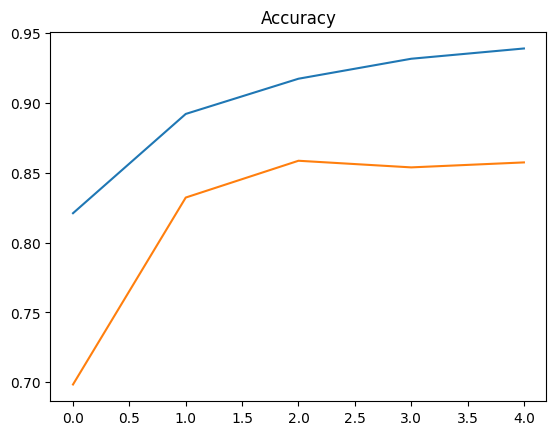

In [48]:
plt.figure(); plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title('Accuracy')
plt.show()

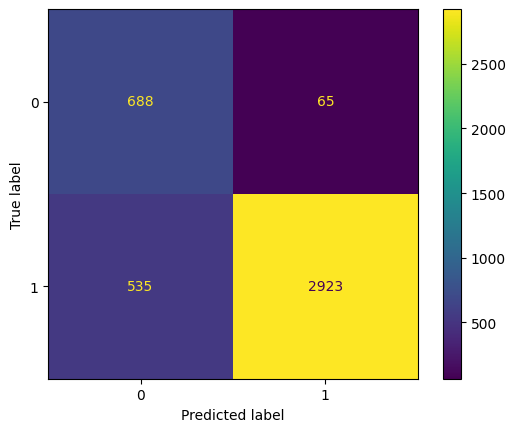

In [49]:
cm=confusion_matrix(labels,preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()